In [31]:
import geopandas as gpd
import pypsa
from shapely.geometry import LineString

# Load shapefiles
gdf_buses = gpd.read_file("qgis/buses_aut.shp").to_crs(epsg=4326)
gdf_lines = gpd.read_file("qgis/lines_aut.shp").to_crs(epsg=4326)

# Initialize PyPSA network
n = pypsa.Network()
n.set_snapshots(range(1))  # Minimal snapshot

gdf_buses = gdf_buses.dropna(subset=["geometry"])

# Add buses
for _, row in gdf_buses.iterrows():
    bus_id = str(row["id"]) # switching to name could be more informative: row name
    n.add("Bus",
          name=bus_id,
          x=row.geometry.x,
          y=row.geometry.y,
          v_nom=row.get("v_ref", 380),
          type=row.get("type", "substation"))
    
# Add extra attributes to buses
n.buses["substation_name"] = gdf_buses["name"].values

# Add lines
for _, row in gdf_lines.iterrows():
    line_geom: LineString = row.geometry
    if line_geom is None or line_geom.is_empty or len(line_geom.coords) < 2:
        continue

    bus0 = str(row["from_node"])
    bus1 = str(row["to_node"])
    #if bus0 not in n.buses.index or bus1 not in n.buses.index:
    #    continue

    n.add("Line",
          name=str(row["id"]),
          bus0=bus0,
          bus1=bus1,
          length=row.get("length", line_geom.length), # / 1000,  # meters → km
          r=row.get("r", 0.05),
          x=row.get("x", 0.2),
          c=row.get("c", 0),
          s_nom=row.get("s_max", 100),
          v_nom=row.get("v_ref", 380),
          type=row.get("type", None))


In [4]:
gdf_buses

,id,name,v_ref,grid_level,comm,decomm,type,geometry
0,19001.0,Simmering,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.43448 48.18282)
1,39001.0,Simmering,380.0,2.0,2024-01-01,2100-01-01,1.0,POINT (16.43448 48.18282)
2,19002.0,Kaiserebersdorf,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.47564 48.15603)
3,13001.0,Schwechat,110.0,3.0,2024-01-01,2100-01-01,5.0,POINT (16.50701 48.13596)
4,19003.0,Wien Suedost,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (16.4203 48.12389)
...,...,...,...,...,...,...,...,...
915,14041.0,Sattledt,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (14.05211 48.08325)
916,14043.0,Pyhrn,110.0,4.0,2024-01-01,2100-01-01,1.0,POINT (14.33004 47.67829)
917,24141.0,Molln,220.0,2.0,2034-01-01,2100-01-01,1.0,POINT (14.24702 47.90342)
918,14141.0,Molln,30.0,4.0,2034-01-01,2100-01-01,1.0,POINT (14.24702 47.90342)


In [5]:
n.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name
Bus,,,,,,,,,,,,,
19001.0,110.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering
39001.0,380.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering
19002.0,110.0,1.0,16.475635,48.156029,AC,,1.0,0.0,inf,PQ,,,Kaiserebersdorf
13001.0,110.0,5.0,16.507006,48.135957,AC,,1.0,0.0,inf,PQ,,,Schwechat
19003.0,110.0,1.0,16.420303,48.123892,AC,,1.0,0.0,inf,PQ,,,Wien Suedost
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14041.0,110.0,1.0,14.052108,48.083252,AC,,1.0,0.0,inf,PQ,,,Sattledt
14043.0,110.0,1.0,14.330044,47.678294,AC,,1.0,0.0,inf,PQ,,,Pyhrn
24141.0,220.0,1.0,14.247019,47.903419,AC,,1.0,0.0,inf,PQ,,,Molln


In [6]:
gdf_lines

,id,name,active,length,i_max,v_ref,r,x,c,comm,decomm,scenario,from_node,to_node,s_max,type,references,geometry
0,14001.0,182/1,1,5.360,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (13.03562 48.22073, 13.03565 48.219..."
1,14002.0,182/2,1,5.340,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (13.08025 48.25504, 13.07976 48.254..."
2,14003.0,182/7,1,6.220,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14003.0,14001.0,89.547027,None,None,"LINESTRING (13.03666 48.22089, 13.03764 48.220..."
3,14004.0,184/1,1,5.830,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14002.0,89.547027,None,None,"LINESTRING (13.07961 48.2557, 13.07874 48.2552..."
4,11030.0,127-9,1,16.189,470.0,110.0,0.2024,0.4329,6.0483,2024-01-01,2365/01/01,BGL,11002.0,11005.0,89.500000,None,None,"LINESTRING (16.89979 47.84484, 16.89925 47.845..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,20600.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20006.0,90000.0,0.000000,None,None,None
2032,20601.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20003.0,90000.0,0.000000,None,None,None
2033,20602.0,None,1,1.000,0.0,220.0,48400.0000,48400.0000,0.0000,2024-01-01,2100/01/01,NIP,20002.0,90000.0,0.000000,None,None,None
2034,31042.0,None,1,0.100,0.0,380.0,0.0000,0.0000,0.0000,2024-01-01,2100/01/01,BGL,31027.0,31020.0,0.000000,None,None,"LINESTRING (16.27613 47.25097, 16.27541 47.25005)"


In [7]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c
Line,,,,,,,,,,,,,,,,,,,,,
14001.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14002.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14003.0,14003.0,14001.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14004.0,14001.0,14002.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
11030.0,11002.0,11005.0,,0.4329,0.2024,0.0,0.0,89.500000,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28065.0,28002.0,28015.0,,0.3106,0.0256,0.0,0.0,777.344402,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
28068.0,28015.0,28050.0,,0.3195,0.0210,0.0,0.0,914.522826,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
39121.0,39003.0,31027.0,,0.2575,0.0151,0.0,0.0,1579.630337,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


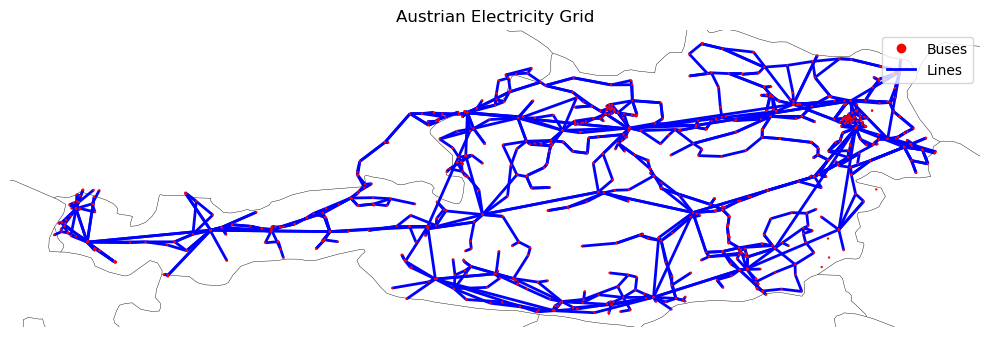

In [8]:
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Plot the network
# Create a figure with GeoAxes using PlateCarree projection (standard lat/lon)
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

n.plot(
    ax=ax,
    line_widths=2,
    bus_sizes=.0001,
    line_colors="blue",
    bus_colors="red",
    title="Austrian Electricity Grid",
)

# Add legend manually
legend_elements = [
    plt.Line2D([0], [0], color='red', marker='o', linestyle='None', label='Buses'),
    plt.Line2D([0], [0], color='blue', lw=2, label='Lines'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


## Tag bus country and get cross border lines

In [9]:
import geopandas as gpd

# Load country borders
gdf_countries = gpd.read_file("data/ne_10m_admin_0_sovereignty.shp").to_crs(epsg=4326)

# Ensure bus geometry is in EPSG:4326
gdf_buses = gdf_buses.to_crs(epsg=4326)

# Spatial join to assign each bus to a country
gdf_buses = gpd.sjoin(gdf_buses, gdf_countries[['geometry', 'NAME_EN']], how='left', predicate='within')
gdf_buses.rename(columns={'NAME_EN': 'country'}, inplace=True)


In [10]:
# Step 1: Separate Austrian and non-Austrian buses
at_buses = gdf_buses[gdf_buses["country"] == "Austria"]
non_at_buses = gdf_buses[gdf_buses["country"] != "Austria"]

# Step 2: Create lookup sets
at_bus_set = set(at_buses["id"])
non_at_bus_set = set(non_at_buses["id"])

# Step 3: Identify cross-border lines
cross_border_mask = (
    (gdf_lines["from_node"].isin(at_bus_set) & gdf_lines["to_node"].isin(non_at_bus_set)) |
    (gdf_lines["to_node"].isin(at_bus_set) & gdf_lines["from_node"].isin(non_at_bus_set))
)

gdf_cross_border_lines = gdf_lines[cross_border_mask].copy()

# Optional: Tag all lines
gdf_lines["cross_border"] = cross_border_mask

# Report
print(f"Detected {len(gdf_cross_border_lines)} cross-border lines.")


Detected 55 cross-border lines.


In [11]:
gdf_lines["geometry"].isna

<bound method GeoSeries.isna of 0       LINESTRING (13.03562 48.22073, 13.03565 48.219...
1       LINESTRING (13.08025 48.25504, 13.07976 48.254...
2       LINESTRING (13.03666 48.22089, 13.03764 48.220...
3       LINESTRING (13.07961 48.2557, 13.07874 48.2552...
4       LINESTRING (16.89979 47.84484, 16.89925 47.845...
                              ...                        
2031                                                 None
2032                                                 None
2033                                                 None
2034    LINESTRING (16.27613 47.25097, 16.27541 47.25005)
2035    LINESTRING (16.27613 47.25097, 16.27541 47.25005)
Name: geometry, Length: 2036, dtype: geometry>

<Axes: >

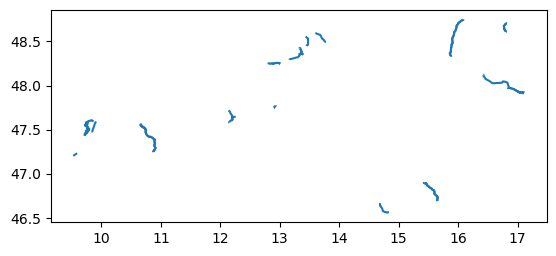

In [12]:
gdf_cross_border_lines.plot()

## Add additional attributes to pypsa network   

In [13]:
n.buses["country"] = gdf_buses["country"].values

In [14]:
n.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name,country
Bus,,,,,,,,,,,,,,
19001.0,110.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
39001.0,380.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
19002.0,110.0,1.0,16.475635,48.156029,AC,,1.0,0.0,inf,PQ,,,Kaiserebersdorf,Austria
13001.0,110.0,5.0,16.507006,48.135957,AC,,1.0,0.0,inf,PQ,,,Schwechat,Austria
19003.0,110.0,1.0,16.420303,48.123892,AC,,1.0,0.0,inf,PQ,,,Wien Suedost,Austria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14041.0,110.0,1.0,14.052108,48.083252,AC,,1.0,0.0,inf,PQ,,,Sattledt,Austria
14043.0,110.0,1.0,14.330044,47.678294,AC,,1.0,0.0,inf,PQ,,,Pyhrn,Austria
24141.0,220.0,1.0,14.247019,47.903419,AC,,1.0,0.0,inf,PQ,,,Molln,Austria


## Mark cross-border lines in pypsa

In [16]:
foreign_buses = n.buses[n.buses["country"] != "Austria"]

In [17]:
foreign_buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name,country
Bus,,,,,,,,,,,,,,
17051.0,110.0,2.0,12.200888,47.641024,AC,,1.0,0.0,inf,PQ,,,Oberaudorf-Ebbs,Germany
17089.0,110.0,3.0,12.372289,48.002385,AC,,1.0,0.0,inf,PQ,,,D-K3,Germany
17090.0,110.0,3.0,12.372304,48.002376,AC,,1.0,0.0,inf,PQ,,,D-K4,Germany
17091.0,110.0,3.0,12.137436,47.718310,AC,,1.0,0.0,inf,PQ,,,D-K2,Germany
17092.0,110.0,3.0,12.137449,47.718320,AC,,1.0,0.0,inf,PQ,,,D-K1,Germany
14116.0,110.0,3.0,12.811583,48.182329,AC,,1.0,0.0,inf,PQ,,,D-K5,Germany
14117.0,110.0,3.0,12.890754,48.217725,AC,,1.0,0.0,inf,PQ,,,D-K6,Germany
14118.0,110.0,3.0,12.794289,48.252434,AC,,1.0,0.0,inf,PQ,,,D-K7,Germany
14119.0,110.0,3.0,13.163605,48.294840,AC,,1.0,0.0,inf,PQ,,,D-K8,Germany


In [18]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c
Line,,,,,,,,,,,,,,,,,,,,,
14001.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14002.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14003.0,14003.0,14001.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
14004.0,14001.0,14002.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
11030.0,11002.0,11005.0,,0.4329,0.2024,0.0,0.0,89.500000,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28065.0,28002.0,28015.0,,0.3106,0.0256,0.0,0.0,777.344402,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
28068.0,28015.0,28050.0,,0.3195,0.0210,0.0,0.0,914.522826,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000
39121.0,39003.0,31027.0,,0.2575,0.0151,0.0,0.0,1579.630337,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000


In [19]:
cross_border_lines = n.lines[n.lines["bus0"].isin(foreign_buses.index) | n.lines["bus1"].isin(foreign_buses.index)]

In [20]:
cross_border_lines # better double check that

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c
Line,,,,,,,,,,,,,,,,,,,,,
14013.0,14004.0,14107.0,,0.4031,0.1594,0.0,0.0,93.548064,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18021.0,18010.0,18042.0,,0.4046,0.2049,0.0,0.0,77.543915,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18040.0,18035.0,18025.0,,0.1574,0.1515,0.0,0.0,83.831259,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14009.0,14105.0,14119.0,,0.3980,0.1013,0.0,0.0,131.272131,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14010.0,14119.0,14108.0,,0.3980,0.1013,0.0,0.0,131.272131,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37160.0,37021.0,30009.0,,0.2647,0.0347,0.0,0.0,1574.364902,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37161.0,37021.0,30010.0,,0.2647,0.0347,0.0,0.0,1181.431856,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28059.0,28046.0,20001.0,,0.2808,0.0570,0.0,0.0,457.261413,0.0,False,...,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
n.lines.index.isin(cross_border_lines.index)

array([False, False, False, ..., False, False, False])

In [23]:
n.lines["cross_border"] = n.lines.index.isin(cross_border_lines.index)


In [24]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c,cross_border
Line,,,,,,,,,,,,,,,,,,,,,
14001.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
14002.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
14003.0,14003.0,14001.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
14004.0,14001.0,14002.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
11030.0,11002.0,11005.0,,0.4329,0.2024,0.0,0.0,89.500000,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0483,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28065.0,28002.0,28015.0,,0.3106,0.0256,0.0,0.0,777.344402,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
28068.0,28015.0,28050.0,,0.3195,0.0210,0.0,0.0,914.522826,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
39121.0,39003.0,31027.0,,0.2575,0.0151,0.0,0.0,1579.630337,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


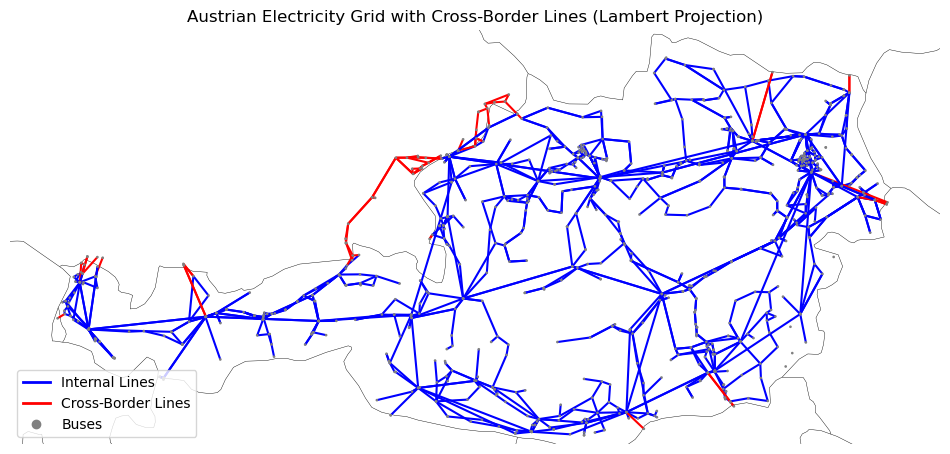

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.lines as mlines

# Define Lambert Conformal projection centered over Austria
projection = ccrs.LambertConformal(central_longitude=13.3, central_latitude=47.5)

# Create custom line colors for cross-border lines
line_colors = n.lines["cross_border"].map({True: "red", False: "blue"})

# Create the plot with the projection
fig, ax = plt.subplots(
    figsize=(12, 12),
    subplot_kw={"projection": projection}
)

# Plot the network
n.plot(
    ax=ax,
    geomap=True,
    projection=projection,
    line_colors=line_colors,
    line_widths=1.5,
    bus_sizes=.0001,
    bus_colors="gray",
    title="Austrian Electricity Grid with Cross-Border Lines (Lambert Projection)",
)

# Add manual legend
legend_elements = [
    mlines.Line2D([], [], color='blue', lw=2, label='Internal Lines'),
    mlines.Line2D([], [], color='red', lw=2, label='Cross-Border Lines'),
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=6, label='Buses'),
]
ax.legend(handles=legend_elements, loc="lower left")


In [26]:
# Set of foreign buses
foreign_bus_set = set(foreign_buses.index)

# Identify cross-border lines: exactly one of bus0 or bus1 must be foreign
is_foreign_0 = n.lines["bus0"].isin(foreign_bus_set)
is_foreign_1 = n.lines["bus1"].isin(foreign_bus_set)
cross_border_mask = is_foreign_0 ^ is_foreign_1  # XOR: True if only one is foreign

# Assign to network
n.lines["cross_border"] = cross_border_mask


In [27]:
n.lines["cross_border"].sum()

38

In [28]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c,cross_border
Line,,,,,,,,,,,,,,,,,,,,,
14001.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
14002.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
14003.0,14003.0,14001.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
14004.0,14001.0,14002.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
11030.0,11002.0,11005.0,,0.4329,0.2024,0.0,0.0,89.500000,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0483,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28065.0,28002.0,28015.0,,0.3106,0.0256,0.0,0.0,777.344402,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
28068.0,28015.0,28050.0,,0.3195,0.0210,0.0,0.0,914.522826,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False
39121.0,39003.0,31027.0,,0.2575,0.0151,0.0,0.0,1579.630337,0.0,False,...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,False


## Export Pypsa-AT Network

In [30]:
n.export_to_netcdf("pypsa_nc/austria_network.nc")

INFO:pypsa.io:Exported network 'austria_network.nc' contains: buses, lines


<xarray.Dataset> Size: 153kB
Dimensions:                       (snapshots: 1, investment_periods: 0,
                                   buses_i: 919, lines_i: 1394)
Coordinates:
  * snapshots                     (snapshots) int64 8B 0
  * investment_periods            (investment_periods) object 0B 
  * buses_i                       (buses_i) object 7kB '19001.0' ... '12005.0'
  * lines_i                       (lines_i) object 11kB '14001.0' ... '31042.0'
Data variables: (12/21)
    snapshots_snapshot            (snapshots) int64 8B 0
    snapshots_objective           (snapshots) float64 8B 1.0
    snapshots_stores              (snapshots) float64 8B 1.0
    snapshots_generators          (snapshots) float64 8B 1.0
    investment_periods_objective  (investment_periods) object 0B 
    investment_periods_years      (investment_periods) object 0B 
    ...                            ...
    lines_x                       (lines_i) float64 11kB 0.3824 0.3824 ... 0.0
    lines_r                       (lines_i) float64 11kB 0.0557 0.0557 ... 0.0
    lines_s_nom                   (lines_i) float64 11kB 205.2 205.2 ... 0.0
    lines_length                  (lines_i) float64 11kB 5.36 5.34 ... 92.2 0.1
    lines_c                       (lines_i) float64 11kB 0.0 0.0 0.0 ... 0.0 0.0
    lines_cross_border            (lines_i) bool 1kB False False ... False False
Attributes:
    network_name:           
    network_pypsa_version:  0.33.2
    network_srid:           4326
    crs:                    {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"World Geo...
    meta:                   {}

In [14]:
n_test = pypsa.Network("../results/128_wAT_entsoe_finetuned/networks/base_s_128_elec_.nc")

INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x7072a29904a0>,
 <matplotlib.collections.LineCollection at 0x7072a22ccf50>)

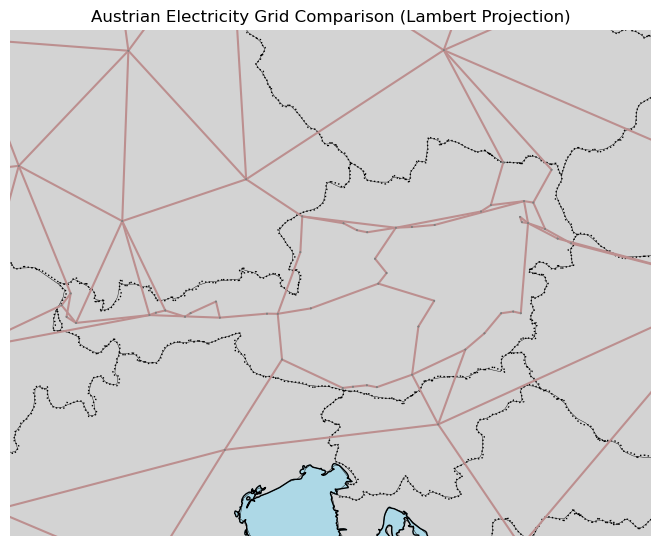

In [22]:
# Define Lambert Conformal projection centered over Austria
projection = ccrs.LambertConformal(central_longitude=13.3, central_latitude=47.5)

# Create custom line colors for cross-border lines
#line_colors = n.lines["cross_border"].map({True: "red", False: "blue"})

projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection

# Define a narrower extent around the central point for a closer zoom
extent_lon_range = 4  # Smaller longitude range for more zoom
extent_lat_range = 3  # Smaller latitude range for more zoom
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]
figsize = (8.27, 11.69)  # Size of the figure (A4)

# Create the plot with the projection
fig, ax = plt.subplots(
    figsize=figsize,
    subplot_kw={"projection": projection}
)

# Set the extent to crop to the center
ax.set_extent(extent, crs=ccrs.PlateCarree())

import cartopy.feature as cfeature
# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network
n_test.plot(
    ax=ax,
    geomap=True,
    projection=projection,
    line_widths=1.5,
    bus_sizes=.0001,
    bus_colors="gray",
    title="Austrian Electricity Grid Comparison (Lambert Projection)",
    boundaries=[9,18,45,50]
)

In [24]:
n_test.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_off,substation_lv,location,country
Bus,,,,,,,,,,,,,,,,
AL0 0,380.0,,19.845426,41.518089,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AL
AT0 0,380.0,,13.899802,48.104391,AC,,1.0,0.0,inf,Slack,AT0 0 CCGT,,1.0,1.0,,AT
AT0 1,380.0,,16.311236,48.205145,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 10,380.0,,15.737397,48.268775,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 11,380.0,,14.711651,48.130419,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SI0 0 battery,1.0,,15.043369,46.170477,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,SI0 0,SI
SK0 0 battery,1.0,,19.227945,48.601176,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,SK0 0,SK
UA0 0 battery,1.0,,25.078479,49.592749,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,UA0 0,UA


In [ ]:
# Loaded variable 'df' from kernel state
df = n_test.buses

# Sort by column: index (ascending)
#df = df.sort_index()

# Filter rows based on column: 'carrier'
df = df[df['carrier'].str.contains("AC", regex=False, na=False, case=False)]

# Filter rows based on column: index
df = df[df.index.str.contains("AT0", regex=False, na=False, case=False)]

In [29]:
df

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_off,substation_lv,location,country
Bus,,,,,,,,,,,,,,,,
AT0 0,380.0,,13.899802,48.104391,AC,,1.0,0.0,inf,Slack,AT0 0 CCGT,,1.0,1.0,,AT
AT0 1,380.0,,16.311236,48.205145,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 10,380.0,,15.737397,48.268775,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 11,380.0,,14.711651,48.130419,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 12,380.0,,14.207810,47.574538,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 13,380.0,,16.675026,48.075721,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 14,380.0,,14.681607,46.668543,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 15,380.0,,16.166650,47.270734,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 16,380.0,,13.220951,47.332631,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT


In [31]:
n.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name,country
Bus,,,,,,,,,,,,,,
19001.0,110.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
39001.0,380.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
19002.0,110.0,1.0,16.475635,48.156029,AC,,1.0,0.0,inf,PQ,,,Kaiserebersdorf,Austria
13001.0,110.0,5.0,16.507006,48.135957,AC,,1.0,0.0,inf,PQ,,,Schwechat,Austria
19003.0,110.0,1.0,16.420303,48.123892,AC,,1.0,0.0,inf,PQ,,,Wien Suedost,Austria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14041.0,110.0,1.0,14.052108,48.083252,AC,,1.0,0.0,inf,PQ,,,Sattledt,Austria
14043.0,110.0,1.0,14.330044,47.678294,AC,,1.0,0.0,inf,PQ,,,Pyhrn,Austria
24141.0,220.0,1.0,14.247019,47.903419,AC,,1.0,0.0,inf,PQ,,,Molln,Austria


In [58]:
n_test.buses['weightings'] = 1
df = n_test.buses['weightings']
bus_weightings = df

In [52]:
df

Bus
AL0 0            1
AT0 0            1
AT0 1            1
AT0 10           1
AT0 11           1
                ..
SI0 0 battery    1
SK0 0 battery    1
UA0 0 battery    1
UA0 1 battery    1
UA0 2 battery    1
Name: weightings, Length: 384, dtype: int64

In [54]:
# Filter rows based on column: 'carrier'
#df = df[df['carrier'].str.contains("AC", regex=False, na=False, case=False)]

# Filter rows based on column: index
df = df[df.index.str.contains("AT0", regex=False, na=False, case=False)]

In [49]:
df

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_off,substation_lv,location,country,weightings
Bus,,,,,,,,,,,,,,,,,
AT0 0,380.0,,13.899802,48.104391,AC,,1.0,0.0,inf,Slack,AT0 0 CCGT,,1.0,1.0,,AT,1
AT0 1,380.0,,16.311236,48.205145,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
AT0 10,380.0,,15.737397,48.268775,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
AT0 11,380.0,,14.711651,48.130419,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
AT0 12,380.0,,14.207810,47.574538,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
AT0 13,380.0,,16.675026,48.075721,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
AT0 14,380.0,,14.681607,46.668543,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
AT0 15,380.0,,16.166650,47.270734,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
AT0 16,380.0,,13.220951,47.332631,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT,1
